## Setup:
Setting up our mutual funds. Note that we have 4 mutual funds [A,B,C,D] with the following distributions/returns:

- A: $Unif[-40\%, 60\%]$
- B: $Unif[-10\%, 24\%]$
- C: $Normal(7\%, (2\%)^2)$
- D: $Unif[5\%, 7\%]$

We will also start with `$1,000,000`. Our goal will be to determine the best investment strategy.

The code below contains several functions about portfolios, which are an array of 4 numbers indicating the amount invested in each stock respectively.

In [76]:
#%pip install numpy matplotlib # uncomment during first run to install dependencies

import numpy as np
import matplotlib.pyplot as plt

NUM_SIMS = 200000
SEED = 0

np.random.seed(SEED)

def setup_portfolios(starting_portfolio, num_portfolios):
        return [starting_portfolio.copy() for _ in range(num_portfolios)]

# Returns a portfolio containing the mean value of each stock across all portfolios
def get_mean_portfolio(portfolios):
        return np.mean(portfolios, axis=0)

# Returns an array of the values of a specific stock type across all portfolios
def filter_portfolios(portfolios, stock_type):
        
        np_arr = np.array(portfolios)

        match stock_type:
                case 'A':
                        return np_arr[:, 0]
                case 'B':
                        return np_arr[:, 1]
                case 'C':
                        return np_arr[:, 2]
                case 'D':
                        return np_arr[:, 3]

# Returns the profit or loss of a portfolio as a decimal of the starting value
def calculate_return(ending_portfolio, starting_portfolio):
        end_value = np.sum(ending_portfolio)
        start_value = np.sum(starting_portfolio)
        return (end_value - start_value) / start_value

# Returns the number of portfolios that have a total value greater than the threshold
def count_successful_portfolios(portfolios, threshold):
        portfolio_values = np.sum(portfolios, axis=1)
        return np.count_nonzero(portfolio_values > threshold)

# Returns the number of portfolios that have a total value less than or equal to the threshold
def count_failed_portfolios(portfolios, threshold):
        portfolio_values = np.sum(portfolios, axis=1)
        return np.count_nonzero(portfolio_values <= threshold)

# Simulates one year of returns for a single portfolio
def simulate_once(portfolio):
        change_a = np.random.uniform(-0.4, 0.6)
        change_b = np.random.uniform(-0.1, 0.24)
        change_c = np.random.normal(0.07, 0.02)
        change_d = np.random.uniform(0.05, 0.07)

        portfolio[0] *= (1 + change_a)
        portfolio[1] *= (1 + change_b)
        portfolio[2] *= (1 + change_c)
        portfolio[3] *= (1 + change_d)

# Simulates multiple years of returns for a list of portfolios
def simulate_multiple(portfolios, num_years):
        for _ in range(num_years):
                for portfolio in portfolios:
                        simulate_once(portfolio)

### Question 1:

##### What is the expected return if you invest option A for 3 years? 

Average after 3 years: $1,331,668.42
Average return after 3 years: 33.17%
Minimum portfolio value: $226,990.03
Maximum portfolio value: $4,039,143.81
IQR: $827,402.99


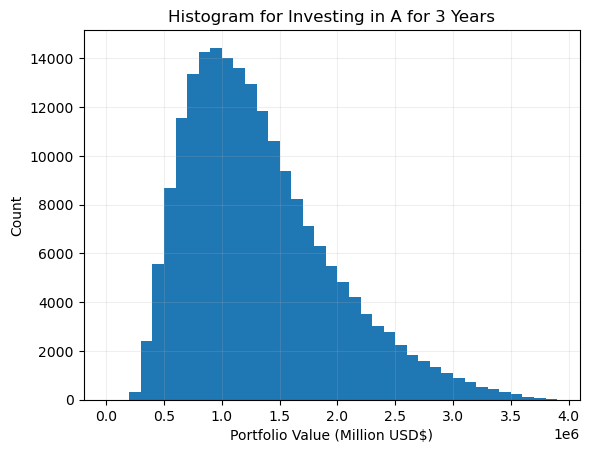

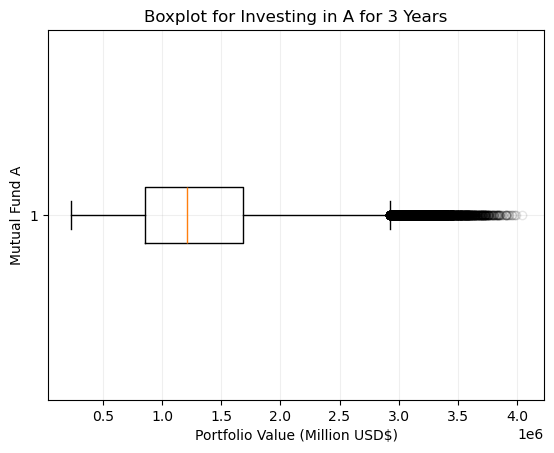

In [77]:
STARTING_PORTFOLIO = [1000000, 0, 0, 0]  # $1,000,000 in asset A, $0 in B, C, D
NUM_YEARS_SHORT = 3
NUM_YEARS_LONG = 10

portfolios = setup_portfolios(STARTING_PORTFOLIO, NUM_SIMS)

simulate_multiple(portfolios, NUM_YEARS_SHORT)

mean_portfolio = get_mean_portfolio(portfolios)

print(f"Average after {NUM_YEARS_SHORT} years: ${np.sum(mean_portfolio):,.2f}")
print(f"Average return after {NUM_YEARS_SHORT} years: {(calculate_return(mean_portfolio, STARTING_PORTFOLIO) * 100):.2f}%")

fund_A_values = filter_portfolios(portfolios, "A")

print(f"Minimum portfolio value: ${np.min(fund_A_values):,.2f}")
print(f"Maximum portfolio value: ${np.max(fund_A_values):,.2f}")

q75, q25 = np.percentile(fund_A_values, [75, 25])
iqr = q75 - q25
print(f"IQR: ${iqr:,.2f}")


plt.figure(1)
histogram = plt.hist(fund_A_values, bins=range(0, 4000000, 100000)) # each bin will be 100k
plt.grid(alpha=0.2)
plt.title("Histogram for Investing in A for 3 Years")
plt.xlabel("Portfolio Value (Million USD$)")
plt.ylabel("Count")

plt.figure(2)
box_plot = plt.boxplot(fund_A_values, vert=False, flierprops={"alpha": 0.1})
plt.grid(alpha=0.2)
plt.title("Boxplot for Investing in A for 3 Years")
plt.xlabel("Portfolio Value (Million USD$)")
plt.ylabel("Mutual Fund A")

plt.show()

##### What is the probability that your profit is more than 25%? 

$ P(T > 1,250,000) =  ? $

In [78]:
print(f"Percentage of portfolios with over $1,250,000 after {NUM_YEARS_SHORT} years: {(count_successful_portfolios(portfolios, 1250000) / NUM_SIMS) * 100:.2f}%")

Percentage of portfolios with over $1,250,000 after 3 years: 47.64%


##### What is the probability that you lose 25% of your money?

$ P(T \le 750,000) = ?$

In [79]:
print(f"Percentage of portfolios with $750,000 or less after {NUM_YEARS_SHORT} years: {(count_failed_portfolios(portfolios, 750000) / NUM_SIMS) * 100:.2f}%")

Percentage of portfolios with $750,000 or less after 3 years: 17.52%


### Question 2:
##### What are your answers if you invest in fund B or C? And what is your recommendation for the best option?

Average after 3 years: $1,224,632.43
Average return after 3 years: 22.46%
Minimum portfolio value: $738,341.00
Maximum portfolio value: $1,891,041.52
IQR: $273,187.84


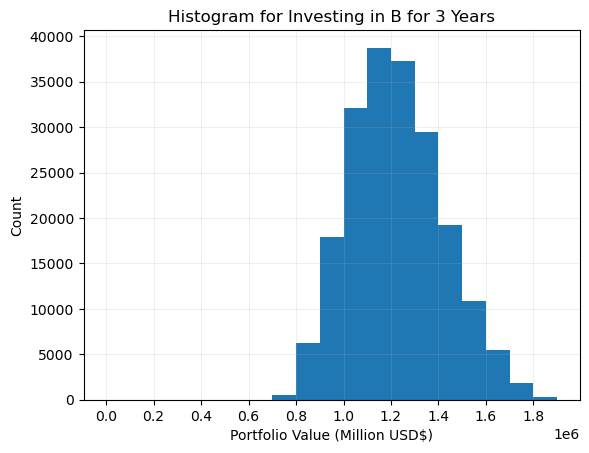

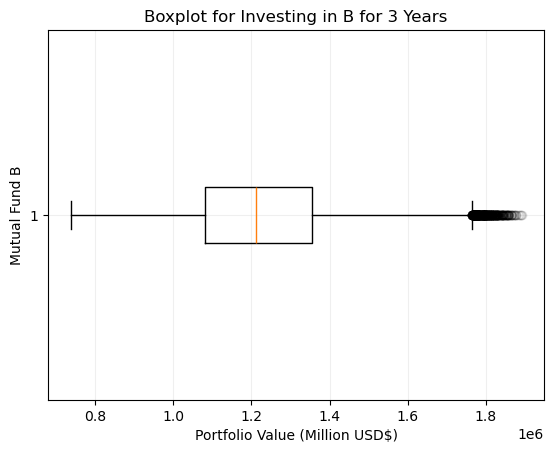

In [80]:
# simulation for fund B

STARTING_PORTFOLIO = [0, 1000000, 0, 0]  # $1,000,000 in asset B, $0 in A, C, D
NUM_YEARS_SHORT = 3

portfolios = setup_portfolios(STARTING_PORTFOLIO, NUM_SIMS)

simulate_multiple(portfolios, NUM_YEARS_SHORT)

mean_portfolio = get_mean_portfolio(portfolios)

print(f"Average after {NUM_YEARS_SHORT} years: ${np.sum(mean_portfolio):,.2f}")
print(f"Average return after {NUM_YEARS_SHORT} years: {(calculate_return(mean_portfolio, STARTING_PORTFOLIO) * 100):.2f}%")

fund_B_values = filter_portfolios(portfolios, "B")

print(f"Minimum portfolio value: ${np.min(fund_B_values):,.2f}")
print(f"Maximum portfolio value: ${np.max(fund_B_values):,.2f}")

q75, q25 = np.percentile(fund_B_values, [75, 25])
iqr = q75 - q25
print(f"IQR: ${iqr:,.2f}")


plt.figure(1)
histogram = plt.hist(fund_B_values, bins=range(0, 2000000, 100000)) # each bin will be 100k
plt.xticks(ticks=range(0,2000000,200000))
plt.grid(alpha=0.2)
plt.title("Histogram for Investing in B for 3 Years")
plt.xlabel("Portfolio Value (Million USD$)")
plt.ylabel("Count")

plt.figure(2)
box_plot = plt.boxplot(fund_B_values, vert=False, flierprops={"alpha": 0.1})
plt.grid(alpha=0.2)
plt.title("Boxplot for Investing in B for 3 Years")
plt.xlabel("Portfolio Value (Million USD$)")
plt.ylabel("Mutual Fund B")

plt.show()


Average after 3 years: $1,225,024.64
Average return after 3 years: 22.50%
Minimum portfolio value: $1,055,930.04
Maximum portfolio value: $1,408,719.34
IQR: $53,398.68


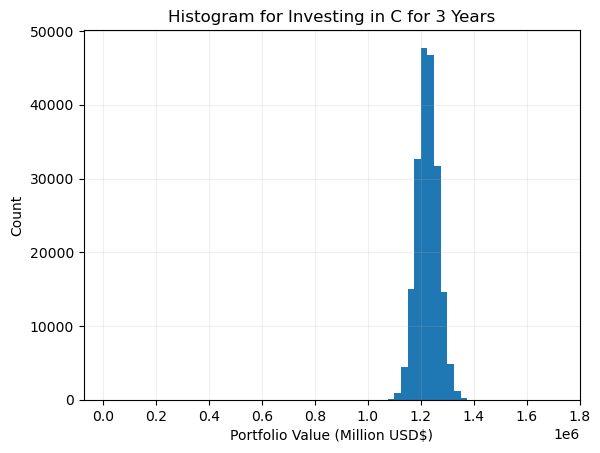

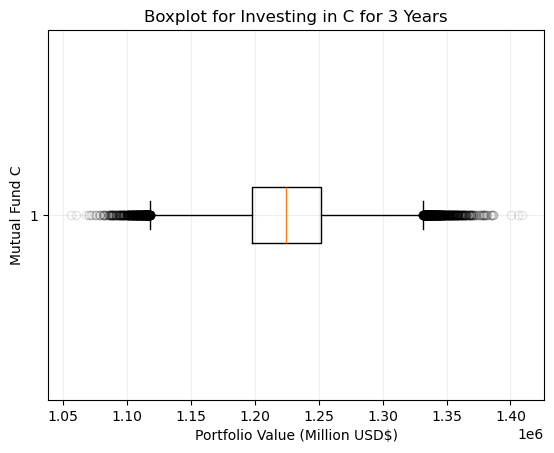

In [81]:
# simulation for fund C

STARTING_PORTFOLIO = [0, 0, 1000000, 0]  # $1,000,000 in asset C, $0 in A, B, D
NUM_YEARS_SHORT = 3

portfolios = setup_portfolios(STARTING_PORTFOLIO, NUM_SIMS)

simulate_multiple(portfolios, NUM_YEARS_SHORT)

mean_portfolio = get_mean_portfolio(portfolios)

print(f"Average after {NUM_YEARS_SHORT} years: ${np.sum(mean_portfolio):,.2f}")
print(f"Average return after {NUM_YEARS_SHORT} years: {(calculate_return(mean_portfolio, STARTING_PORTFOLIO) * 100):.2f}%")

fund_C_values = filter_portfolios(portfolios, "C")

print(f"Minimum portfolio value: ${np.min(fund_C_values):,.2f}")
print(f"Maximum portfolio value: ${np.max(fund_C_values):,.2f}")

q75, q25 = np.percentile(fund_C_values, [75, 25])
iqr = q75 - q25
print(f"IQR: ${iqr:,.2f}")


plt.figure(1)
histogram = plt.hist(fund_C_values, bins=range(0, 1500000, 25000)) # each bin will be 25k
plt.xticks(ticks=range(0,2000000,200000))
plt.grid(alpha=0.2)
plt.title("Histogram for Investing in C for 3 Years")
plt.xlabel("Portfolio Value (Million USD$)")
plt.ylabel("Count")

plt.figure(2)
box_plot = plt.boxplot(fund_C_values, vert=False, flierprops={"alpha": 0.1})
plt.grid(alpha=0.2)
plt.title("Boxplot for Investing in C for 3 Years")
plt.xlabel("Portfolio Value (Million USD$)")
plt.ylabel("Mutual Fund C")

plt.show()


##### What about investing everything in fund D for 3 years?

Average after 3 years: $1,191,032.07
Average return after 3 years: 19.10%
Minimum portfolio value: $1,158,776.70
Maximum portfolio value: $1,224,252.63
IQR: $15,856.64


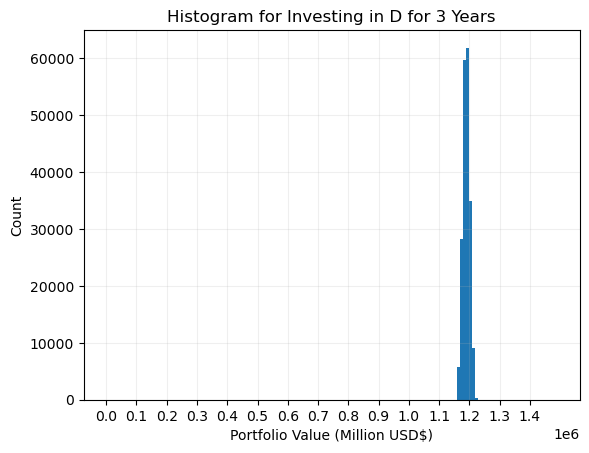

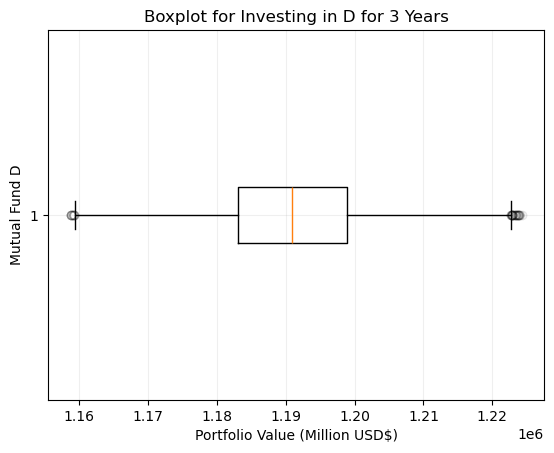

In [82]:
# simulation for fund D

STARTING_PORTFOLIO = [0, 0, 0, 1000000]  # $1,000,000 in asset D, $0 in A, B, C
NUM_YEARS_SHORT = 3

portfolios = setup_portfolios(STARTING_PORTFOLIO, NUM_SIMS)

simulate_multiple(portfolios, NUM_YEARS_SHORT)

mean_portfolio = get_mean_portfolio(portfolios)

print(f"Average after {NUM_YEARS_SHORT} years: ${np.sum(mean_portfolio):,.2f}")
print(f"Average return after {NUM_YEARS_SHORT} years: {(calculate_return(mean_portfolio, STARTING_PORTFOLIO) * 100):.2f}%")

fund_D_values = filter_portfolios(portfolios, "D")

print(f"Minimum portfolio value: ${np.min(fund_D_values):,.2f}")
print(f"Maximum portfolio value: ${np.max(fund_D_values):,.2f}")

q75, q25 = np.percentile(fund_D_values, [75, 25])
iqr = q75 - q25
print(f"IQR: ${iqr:,.2f}")


plt.figure(1)
histogram = plt.hist(fund_D_values, bins=range(0, 1500000, 10000)) # each bin will be 10k
plt.xticks(ticks=range(0,1500000,100000))
plt.grid(alpha=0.2)
plt.title("Histogram for Investing in D for 3 Years")
plt.xlabel("Portfolio Value (Million USD$)")
plt.ylabel("Count")

plt.figure(2)
box_plot = plt.boxplot(fund_D_values, vert=False, flierprops={"alpha": 0.1})
plt.grid(alpha=0.2)
plt.title("Boxplot for Investing in D for 3 Years")
plt.xlabel("Portfolio Value (Million USD$)")
plt.ylabel("Mutual Fund D")

plt.show()


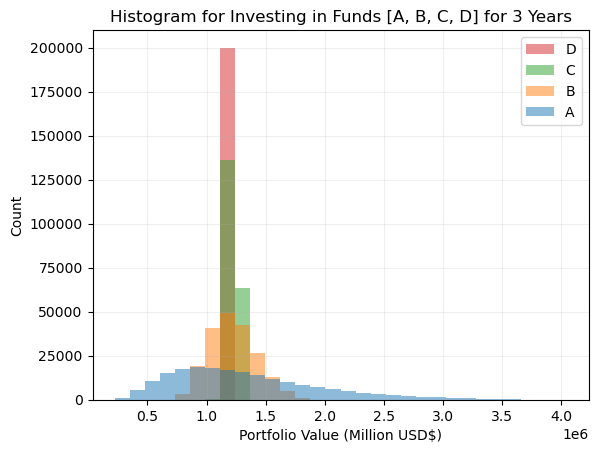

In [92]:
# combining outcomes for funds A, B, C, D into one histogram for simplicity

plt.figure(3)
stacked_hist = plt.hist([fund_A_values, fund_B_values, fund_C_values, fund_D_values], histtype="stepfilled", bins=30, label=["A", "B", "C", "D"], alpha=0.5)

plt.grid(alpha=0.2)
plt.title("Histogram for Investing in Funds [A, B, C, D] for 3 Years")
plt.legend()
plt.xlabel("Portfolio Value (Million USD$)")
plt.ylabel("Count")
plt.show()

*So which is best?*

***markdown cell for analysis!!!***

### Question 3:
##### How will your answer/recommendation change if you are planning for 10 years, instead of 3 years?

### Question 4:

##### Will it be a better strategy if we invest `$500,000` in fund A and `$500,000` in fund D? 

##### Or how about `$600,000` in fund B and `$400,000` in fund C?

### Question 5:

##### Will it be a better strategy if we invest `$500,000` in fund A, `$300,000` in fund B and `$200,000` in fund C?

### Question 6:

##### What is the best strategy you would recommend?

markdown block: ***will put answer here !!!***